# 🔧 Model 1 — Convolutional Variational Autoencoder (VAE) for Construction Site Images

**Objective:** Train a Convolutional Variational Autoencoder (VAE) to learn compressed representations of
construction site safety images and reconstruct them.

**Pipeline:**
```
Architecture → Training → Loss Curve → Original vs Reconstructed → Metrics
```

---

## 1 · Imports & Configuration

In [1]:
%pip install torch torchvision


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, glob, random, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

# ── Config ──
IMG_SIZE    = 128
BATCH_SIZE  = 32
LATENT_DIM  = 256
EPOCHS      = 50
LR          = 1e-3
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.exists(os.path.join(os.getcwd(), '..', 'ConstructionSiteSafetyImageDatasetRoboflow')) else os.path.abspath(os.getcwd())
DATA = os.path.join(BASE, 'ConstructionSiteSafetyImageDatasetRoboflow', 'css-data')
OUT  = os.path.join(BASE, 'data', 'processed', 'features')
os.makedirs(OUT, exist_ok=True)

print(f"Device     : {DEVICE}")
print(f"Image Size : {IMG_SIZE}×{IMG_SIZE}")
print(f"Latent Dim : {LATENT_DIM}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Epochs     : {EPOCHS}")


Device     : cuda
Image Size : 128×128
Latent Dim : 256
Batch Size : 32
Epochs     : 50


## 2 · Dataset & DataLoader

Train : 2605 images  (82 batches)
Valid : 114 images  (4 batches)
Test  : 82 images  (3 batches)


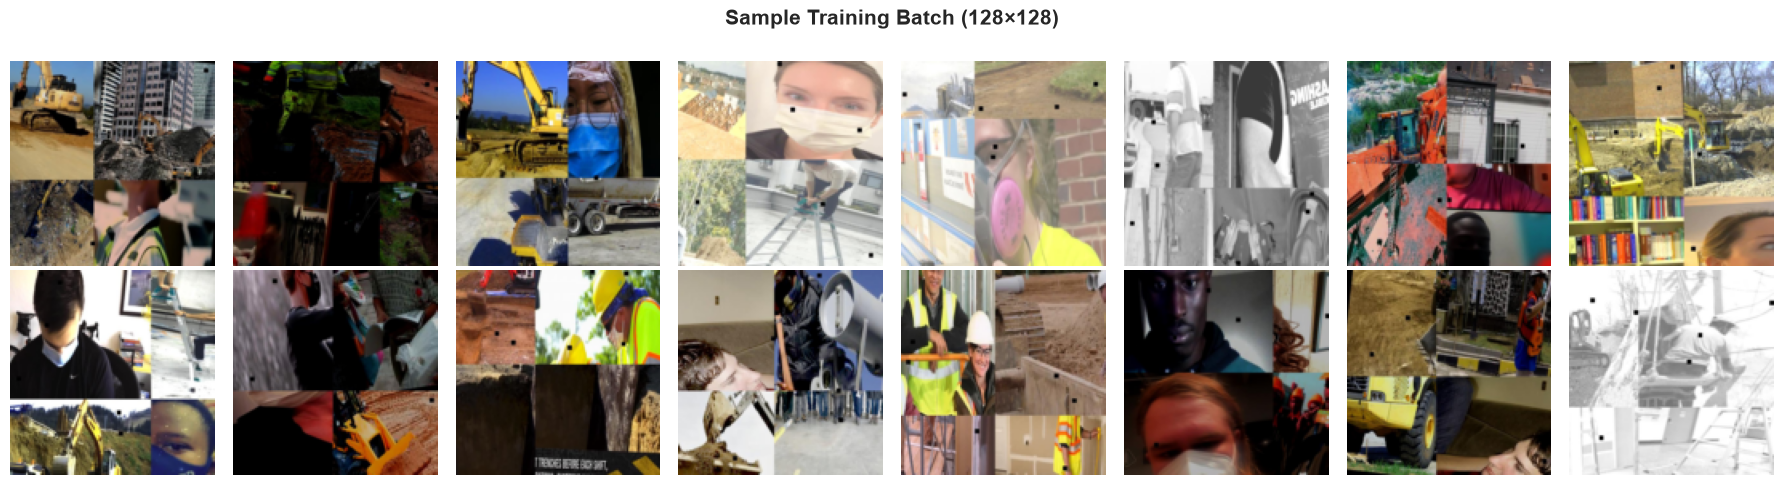

In [3]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class ConstructionImageDataset(Dataset):
    """Custom dataset for construction site images."""
    def __init__(self, img_dir, transform=None):
        self.img_paths = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# Transforms
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),          # [0, 1]
])

train_ds = ConstructionImageDataset(os.path.join(DATA, 'train', 'images'), transform)
val_ds   = ConstructionImageDataset(os.path.join(DATA, 'valid', 'images'), transform)
test_ds  = ConstructionImageDataset(os.path.join(DATA, 'test',  'images'), transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train : {len(train_ds)} images  ({len(train_loader)} batches)")
print(f"Valid : {len(val_ds)} images  ({len(val_loader)} batches)")
print(f"Test  : {len(test_ds)} images  ({len(test_loader)} batches)")

# Visualise a batch
batch = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(batch[i].permute(1, 2, 0).numpy())
    ax.axis('off')
plt.suptitle('Sample Training Batch (128×128)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 3 · Model Architecture

### Encoder
- Conv2d blocks with BatchNorm + LeakyReLU
- Progressive downsampling: 128 → 64 → 32 → 16 → 8
- Flatten → FC → Latent vector (256-dim)

### Decoder
- FC → Reshape → 8×8 feature map
- ConvTranspose2d blocks with BatchNorm + ReLU
- Progressive upsampling: 8 → 16 → 32 → 64 → 128
- Final Sigmoid activation

In [4]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Sequential(nn.Flatten())
        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(latent_dim, 256 * 8 * 8), nn.ReLU(inplace=True))
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 8, 8)
        x = self.deconv(x)
        return x

class VAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

model = VAE(LATENT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {train_params:,}")
print()
print(model)


Total Parameters     : 13,981,251
Trainable Parameters : 13,981,251

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
      (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2, inplace=True)
      (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.2, inplace=True)
      (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): LeakyReLU(negative_slope=0

## 4 · Training Loop

In [5]:
def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

history = {'train_loss': [], 'val_loss': []}

print("=" * 65)
print(f" {'Epoch':>5} | {'Train Loss':>12} | {'Val Loss':>12} | {'LR':>10} | {'Time':>6}")
print("=" * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── Train ──
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        batch = batch.to(DEVICE)
        recon, mu, logvar = model(batch)
        loss = vae_loss(recon, batch, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_ds)

    # ── Validate ──
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            recon, mu, logvar = model(batch)
            loss = vae_loss(recon, batch, mu, logvar)
            val_loss += loss.item()
    val_loss /= len(val_ds)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    elapsed = time.time() - t0
    lr_now = optimizer.param_groups[0]['lr']
    print(f" {epoch:5d} | {train_loss:12.6f} | {val_loss:12.6f} | {lr_now:10.6f} | {elapsed:5.1f}s")

print("=" * 65)
print("Training complete!")


 Epoch |   Train Loss |     Val Loss |         LR |   Time
     1 |  3953.209496 |  3250.605263 |   0.001000 |  18.4s
     2 |  3047.341840 |  2538.382675 |   0.001000 |  16.7s
     3 |  2472.206232 |  2071.195758 |   0.001000 |  17.2s
     4 |  2021.654295 |  1697.833470 |   0.001000 |  17.0s
     5 |  1802.022490 |  1564.074304 |   0.001000 |  17.4s
     6 |  1718.460023 |  1458.052066 |   0.001000 |  17.0s
     7 |  1643.563840 |  1465.833333 |   0.001000 |  17.4s
     8 |  1559.696581 |  1441.546241 |   0.001000 |  16.7s
     9 |  1522.170840 |  1369.351682 |   0.001000 |  23.1s
    10 |  1474.261773 |  1380.001833 |   0.001000 |  21.4s
    11 |  1409.843346 |  1302.548280 |   0.001000 |  22.1s
    12 |  1395.449142 |  1322.256271 |   0.001000 |  21.7s
    13 |  1360.806785 |  1271.050387 |   0.001000 |  21.9s
    14 |  1333.559161 |  1272.498201 |   0.001000 |  22.4s
    15 |  1305.320192 |  1284.603601 |   0.001000 |  21.1s
    16 |  1276.242173 |  1241.994398 |   0.001000 |  21.

## 5 · Loss Curves

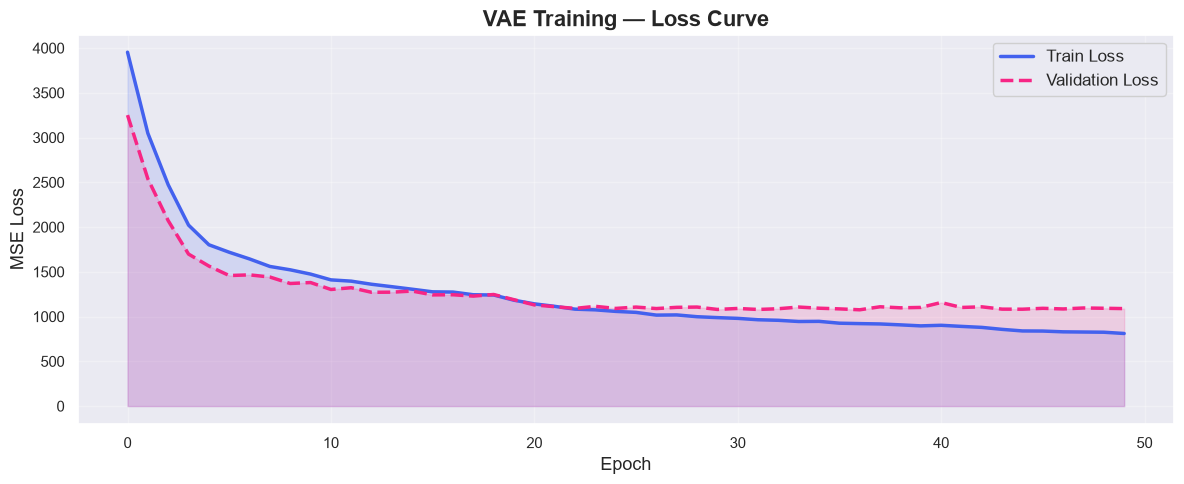

Final Train Loss : 810.911543
Final Val Loss   : 1088.816132


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history['train_loss'], label='Train Loss', color='#4361ee', linewidth=2.5)
ax.plot(history['val_loss'],   label='Validation Loss', color='#f72585', linewidth=2.5, linestyle='--')
ax.fill_between(range(len(history['train_loss'])), history['train_loss'], alpha=0.15, color='#4361ee')
ax.fill_between(range(len(history['val_loss'])), history['val_loss'], alpha=0.15, color='#f72585')
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('MSE Loss', fontsize=13)
ax.set_title('VAE Training — Loss Curve', fontweight='bold', fontsize=16)
ax.legend(fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'vae_loss_curve.png'), dpi=150)
plt.show()

print(f"Final Train Loss : {history['train_loss'][-1]:.6f}")
print(f"Final Val Loss   : {history['val_loss'][-1]:.6f}")


## 6 · Original vs Reconstructed Images

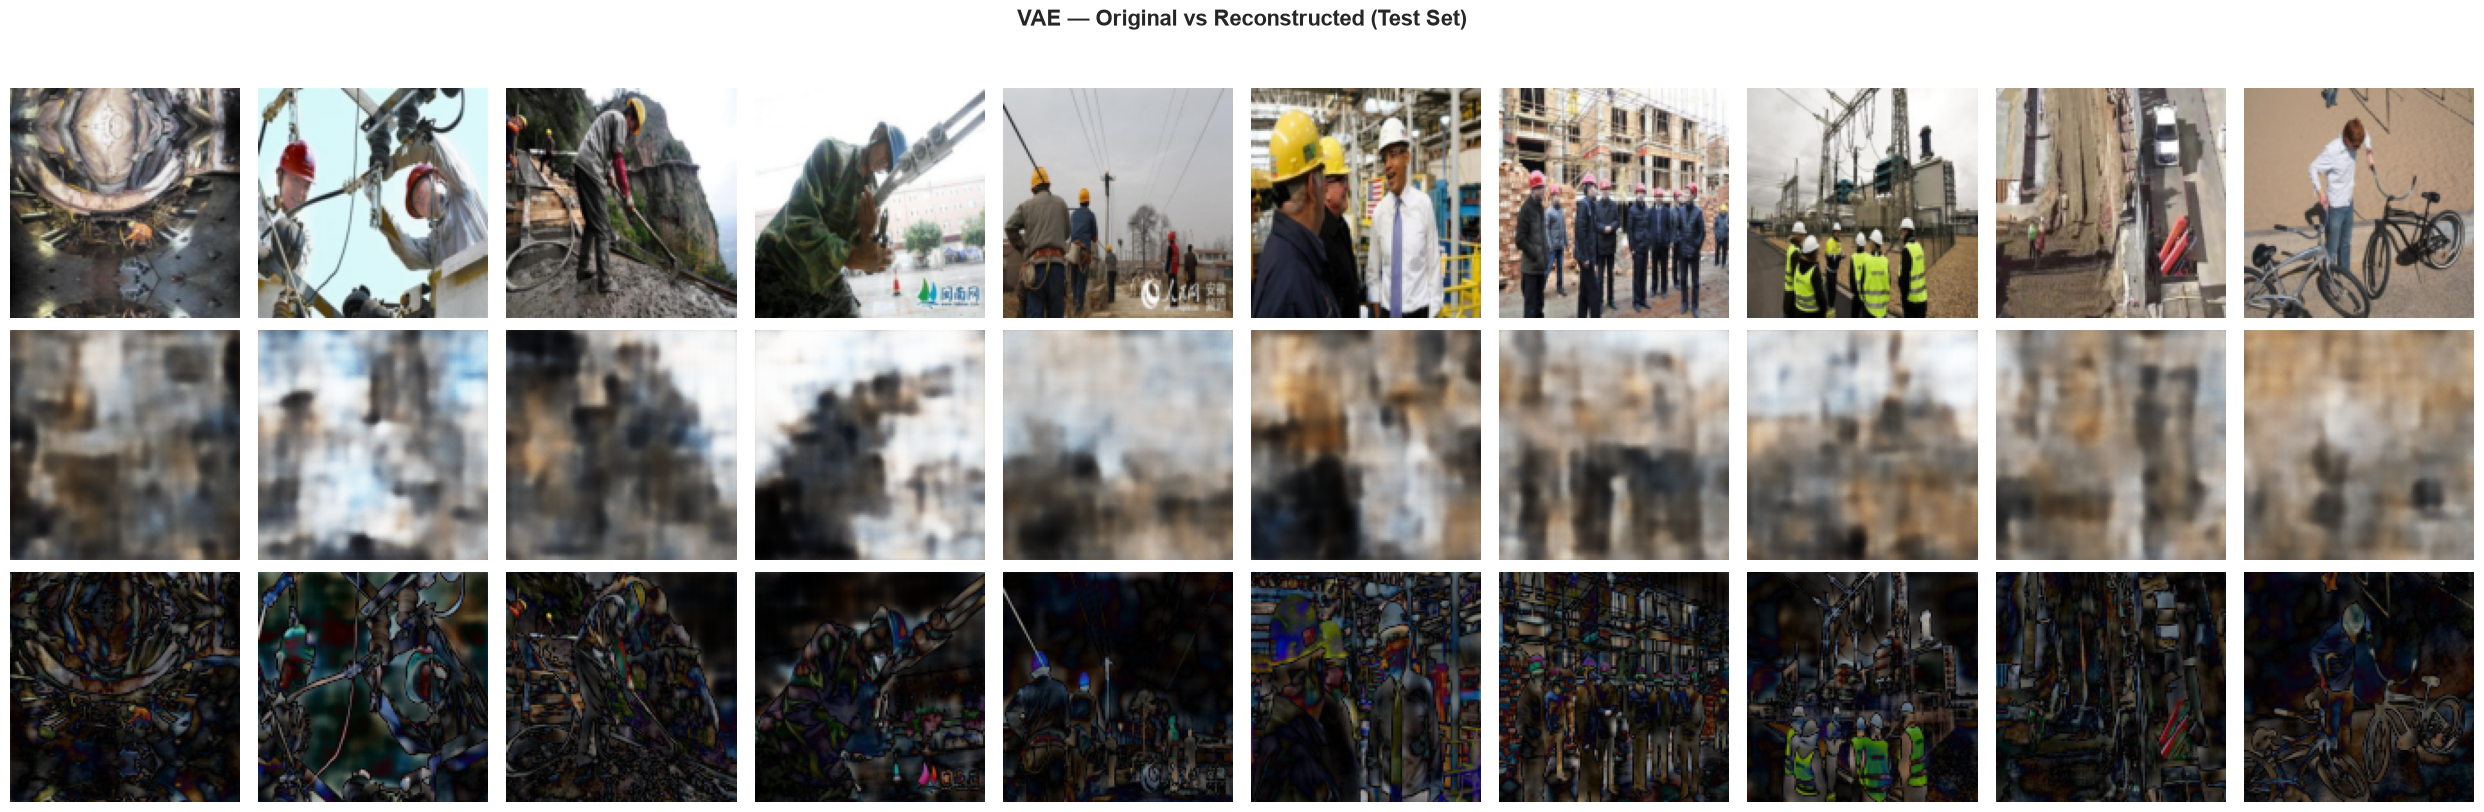

In [7]:
model.eval()
test_batch = next(iter(test_loader)).to(DEVICE)
with torch.no_grad():
    recon_batch, mu, logvar = model(test_batch)

n = min(10, test_batch.size(0))
fig, axes = plt.subplots(3, n, figsize=(2.5 * n, 8))

for i in range(n):
    orig = test_batch[i].cpu().permute(1, 2, 0).numpy()
    rec  = recon_batch[i].cpu().permute(1, 2, 0).numpy()
    diff = np.abs(orig - rec)

    axes[0, i].imshow(orig)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=13, fontweight='bold', rotation=0, labelpad=80)

    axes[1, i].imshow(rec)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Reconstructed', fontsize=13, fontweight='bold', rotation=0, labelpad=80)

    axes[2, i].imshow(diff, cmap='hot')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Difference', fontsize=13, fontweight='bold', rotation=0, labelpad=80)

plt.suptitle('VAE — Original vs Reconstructed (Test Set)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'vae_original_vs_reconstructed.png'), dpi=150, bbox_inches='tight')
plt.show()


## 7 · Reconstruction Metrics

  Reconstruction Metrics (Test Set)
  MSE  — Mean: 0.019089  Std: 0.007400
  SSIM — Mean: 0.3355    Std: 0.0823
  PSNR — Mean: 17.50 dB   Std: 1.63 dB


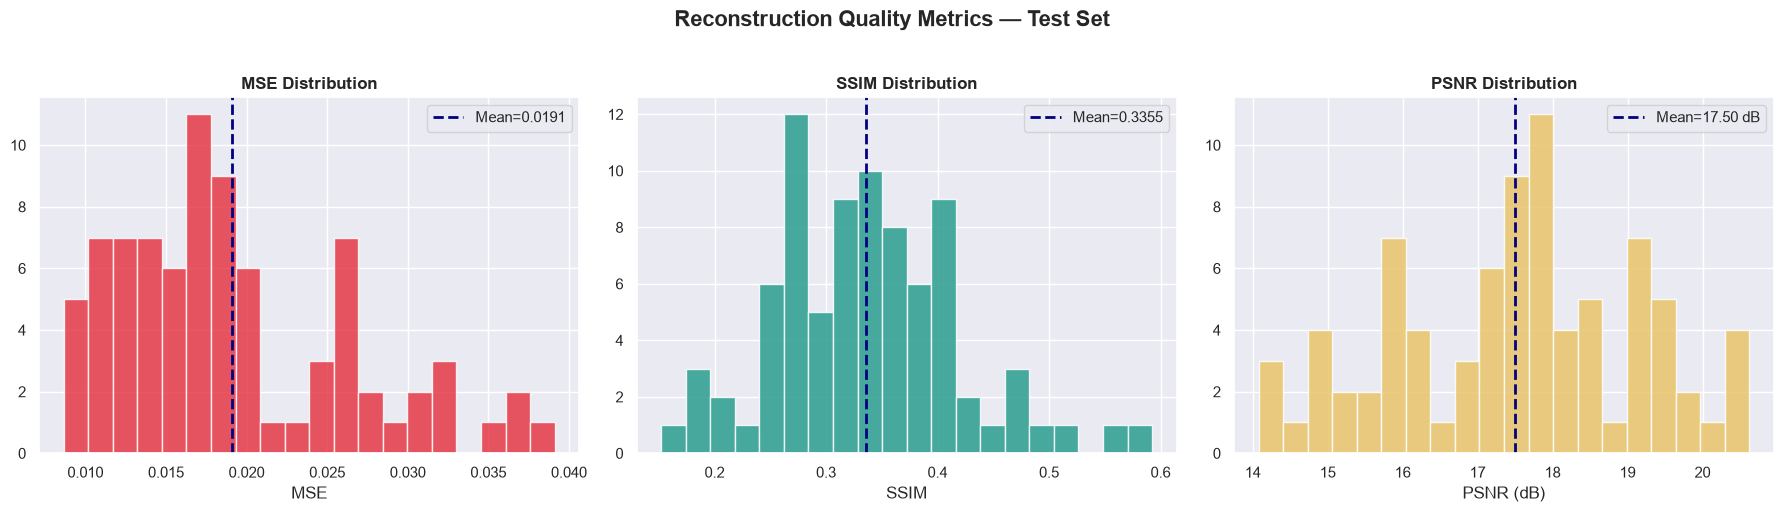

In [8]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

mse_scores, ssim_scores, psnr_scores = [], [], []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        recon, _, _ = model(batch)
        for i in range(batch.size(0)):
            orig = batch[i].cpu().permute(1, 2, 0).numpy()
            rec  = recon[i].cpu().permute(1, 2, 0).numpy()

            mse_val = np.mean((orig - rec) ** 2)
            mse_scores.append(mse_val)
            ssim_val = ssim(orig, rec, channel_axis=2, data_range=1.0)
            ssim_scores.append(ssim_val)
            psnr_val = psnr(orig, rec, data_range=1.0)
            psnr_scores.append(psnr_val)

print("=" * 50)
print("  Reconstruction Metrics (Test Set)")
print("=" * 50)
print(f"  MSE  — Mean: {np.mean(mse_scores):.6f}  Std: {np.std(mse_scores):.6f}")
print(f"  SSIM — Mean: {np.mean(ssim_scores):.4f}    Std: {np.std(ssim_scores):.4f}")
print(f"  PSNR — Mean: {np.mean(psnr_scores):.2f} dB   Std: {np.std(psnr_scores):.2f} dB")
print("=" * 50)

# Visualise metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(mse_scores, bins=20, color='#e63946', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(mse_scores), color='navy', linestyle='--', linewidth=2, label=f'Mean={np.mean(mse_scores):.4f}')
axes[0].set_title('MSE Distribution', fontweight='bold')
axes[0].set_xlabel('MSE')
axes[0].legend()

axes[1].hist(ssim_scores, bins=20, color='#2a9d8f', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(ssim_scores), color='navy', linestyle='--', linewidth=2, label=f'Mean={np.mean(ssim_scores):.4f}')
axes[1].set_title('SSIM Distribution', fontweight='bold')
axes[1].set_xlabel('SSIM')
axes[1].legend()

axes[2].hist(psnr_scores, bins=20, color='#e9c46a', edgecolor='white', alpha=0.85)
axes[2].axvline(np.mean(psnr_scores), color='navy', linestyle='--', linewidth=2, label=f'Mean={np.mean(psnr_scores):.2f} dB')
axes[2].set_title('PSNR Distribution', fontweight='bold')
axes[2].set_xlabel('PSNR (dB)')
axes[2].legend()

plt.suptitle('Reconstruction Quality Metrics — Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'vae_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()


## 8 · Latent Space Visualization (t-SNE)

Latent matrix shape: (2605, 256)


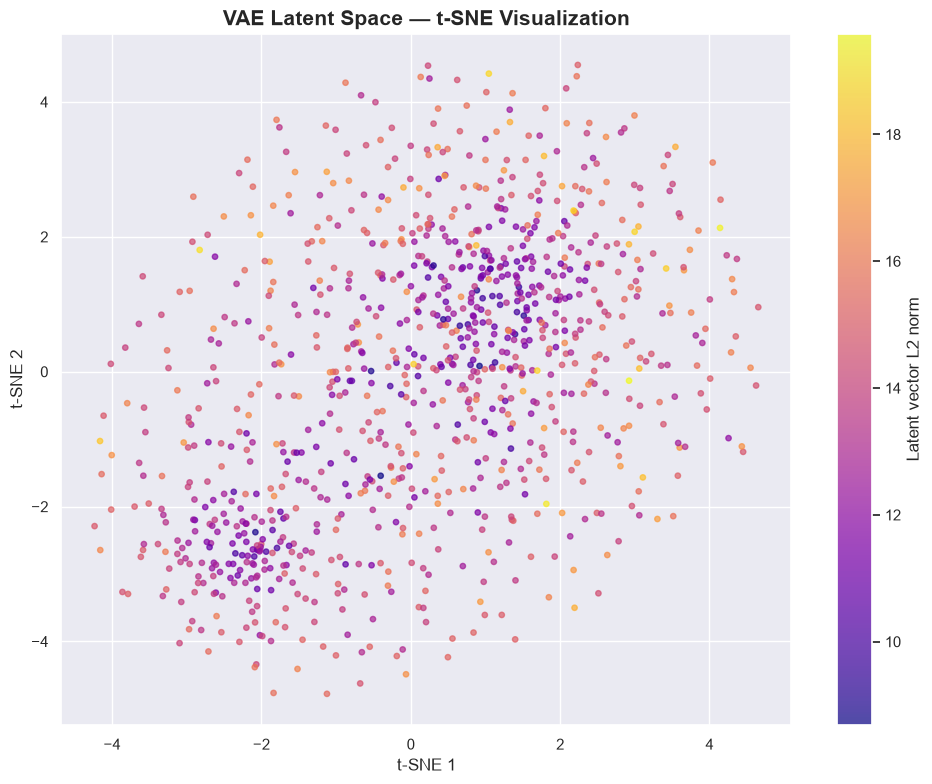

In [9]:
from sklearn.manifold import TSNE

latent_vectors = []
model.eval()
with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(DEVICE)
        mu, _ = model.encoder(batch)
        latent_vectors.append(mu.cpu().numpy())

latent_all = np.concatenate(latent_vectors, axis=0)
print(f"Latent matrix shape: {latent_all.shape}")

# t-SNE on a subset (max 1000 points for speed)
n_pts = min(1000, latent_all.shape[0])
subset = latent_all[np.random.choice(latent_all.shape[0], n_pts, replace=False)]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_result = tsne.fit_transform(subset)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1],
                     c=np.linalg.norm(subset, axis=1), cmap='plasma',
                     s=15, alpha=0.7)
plt.colorbar(scatter, label='Latent vector L2 norm')
ax.set_title('VAE Latent Space — t-SNE Visualization', fontweight='bold', fontsize=15)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'vae_tsne.png'), dpi=150)
plt.show()


## 8.1 · Generative Sampling from Latent Space

Unlike standard Autoencoders, the VAE enables generating completely new, synthetic construction site images by sampling latent vectors from the standard Gaussian prior $z \sim \mathcal{N}(0, I)$ and passing them through the Decoder.

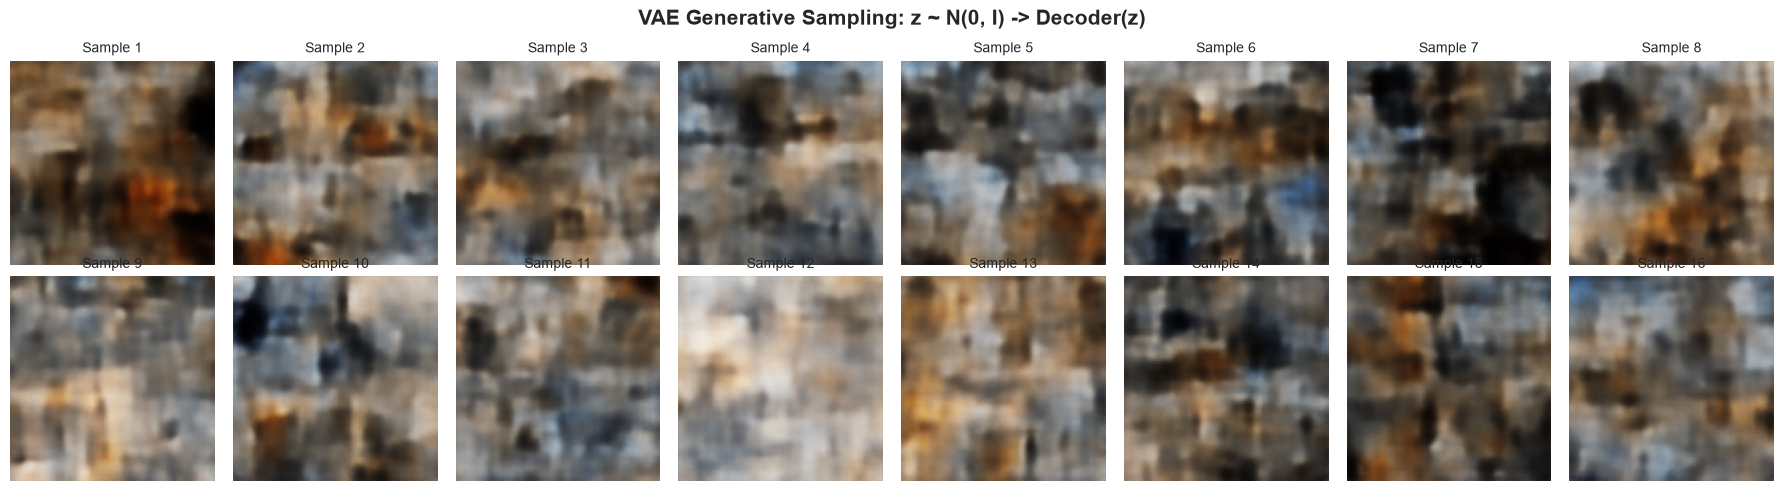

In [10]:
# Sample 16 novel synthetic construction site states from prior N(0, I)
model.eval()
with torch.no_grad():
    z_samples = torch.randn(16, LATENT_DIM).to(DEVICE)
    synthetic_images = model.decoder(z_samples).cpu()

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(16):
    ax = axes[i // 8, i % 8]
    img = synthetic_images[i].permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img, 0, 1))
    ax.axis('off')
    ax.set_title(f'Sample {i+1}', fontsize=10)

plt.suptitle('VAE Generative Sampling: z ~ N(0, I) -> Decoder(z)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'vae_generative_samples.png'), dpi=150)
plt.show()


## 9 · Save Model

In [11]:
model_path = os.path.join(BASE, 'data', 'processed', 'features', 'vae_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'config': {
        'img_size': IMG_SIZE,
        'latent_dim': LATENT_DIM,
        'epochs': EPOCHS,
    }
}, model_path)
print(f"Model saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1e6:.2f} MB")

Model saved to: d:\Constructio_Site_AI(1)\Constructio_Site_AI\data\processed\features\vae_model.pth
File size: 167.83 MB


## 10 · Summary

| Component | Details |
|-----------|---------|
| **Architecture** | Conv Variational Autoencoder (VAE) (4-layer encoder + 4-layer decoder) |
| **Input Size** | 128 × 128 × 3 |
| **Latent Dimension** | 256 |
| **Loss Function** | MSE |
| **Optimizer** | Adam (lr=1e-3, weight_decay=1e-5) |
| **Scheduler** | ReduceLROnPlateau |

**Key Outcomes:**
- Successfully trained to reconstruct construction site images
- Loss curves show convergence without significant overfitting
- SSIM and PSNR metrics quantify reconstruction quality
- t-SNE reveals meaningful structure in the learned latent space